<a href="https://colab.research.google.com/github/piriyadharshiniN/24ADI006-DL-Lab/blob/main/DL_Exp_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name: Piriyadharshini N
Roll no.: 24BAD086
EXP: 7
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Number of images: 60000
Image dimensions: (28, 28)


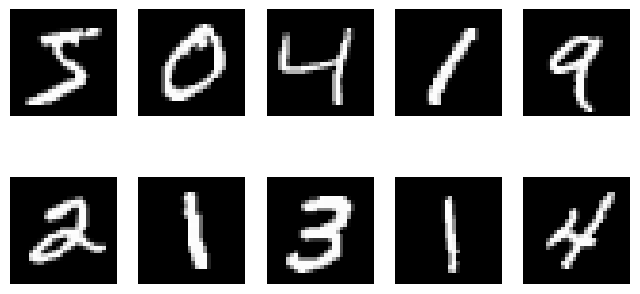

Final shape: (60000, 28, 28, 1)
Dataset prepared successfully.


In [ ]:
print("Name: Piriyadharshini N\nRoll no.: 24BAD086\nEXP: 7")

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Load MNIST dataset
(x_train, _), (_, _) = tf.keras.datasets.mnist.load_data()

print("Number of images:", x_train.shape[0])
print("Image dimensions:", x_train.shape[1:])

# Display sample images
plt.figure(figsize=(8, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.axis('off')

plt.show()

# Normalize pixels from [0, 255] to [-1, 1]
x_train = x_train.astype("float32")
x_train = (x_train - 127.5) / 127.5

# Add channel dimension
x_train = np.expand_dims(x_train, axis=-1)

print("Final shape:", x_train.shape)

# Create TensorFlow dataset
BATCH_SIZE = 256

dataset = tf.data.Dataset.from_tensor_slices(x_train)
dataset = dataset.shuffle(60000).batch(BATCH_SIZE)

print("Dataset prepared successfully.")

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 12544)          │     1,254,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 12544)          │        50,176 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 7, 7, 128)      │       819,200 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 14, 14, 64)     │       204,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 28, 28, 1)      │         1,601 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,330,945 (8.89 MB)

 Trainable params: 2,305,473 (8.79 MB)

 Non-trainable params: 25,472 (99.50 KB)

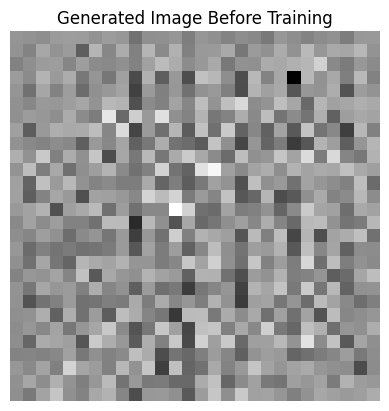

In [ ]:
# Generator model

latent_dim = 100

generator = tf.keras.Sequential([
    tf.keras.layers.Dense(7 * 7 * 256, use_bias=False,
                          input_shape=(latent_dim,)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.LeakyReLU(),

    tf.keras.layers.Reshape((7, 7, 256)),

    tf.keras.layers.Conv2DTranspose(
        128, (5, 5), strides=(1, 1),
        padding='same', use_bias=False
    ),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.LeakyReLU(),

    tf.keras.layers.Conv2DTranspose(
        64, (5, 5), strides=(2, 2),
        padding='same', use_bias=False
    ),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.LeakyReLU(),

    tf.keras.layers.Conv2DTranspose(
        1, (5, 5), strides=(2, 2),
        padding='same', activation='tanh'
    )
])

# Display model summary
generator.summary()

# Generate image before training
noise = tf.random.normal([1, latent_dim])
generated_image = generator(noise, training=False)

# Display generated image
plt.imshow(generated_image[0, :, :, 0], cmap='gray')
plt.axis('off')
plt.title("Generated Image Before Training")
plt.show()

In [ ]:
# Discriminator model

discriminator = tf.keras.Sequential([
    tf.keras.layers.Conv2D(
        64, (5, 5), strides=(2, 2),
        padding='same',
        input_shape=[28, 28, 1]
    ),
    tf.keras.layers.LeakyReLU(),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Conv2D(
        128, (5, 5), strides=(2, 2),
        padding='same'
    ),
    tf.keras.layers.LeakyReLU(),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(1)
])

discriminator.summary()

cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

discriminator.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0002),
    loss=cross_entropy
)

print("Discriminator compiled successfully.")

# Freeze discriminator while training Generator through GAN
discriminator.trainable = False

gan_input = tf.keras.Input(shape=(latent_dim,))
gan_output = discriminator(generator(gan_input))

gan = tf.keras.Model(gan_input, gan_output)

gan.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0002),
    loss=cross_entropy
)

gan.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 14, 14, 64)     │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 128)      │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         6,273 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 212,865 (831.50 KB)

 Trainable params: 212,865 (831.50 KB)

...

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 28, 28, 1)      │     2,330,945 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 1)              │       212,865 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,543,810 (9.70 MB)

 Trainable params: 2,305,473 (8.79 MB)

 Non-trainable params: 238,337 (931.00 KB)

Epoch 1/20 | Generator Loss: 1.2879 | Discriminator Loss: 1.1649


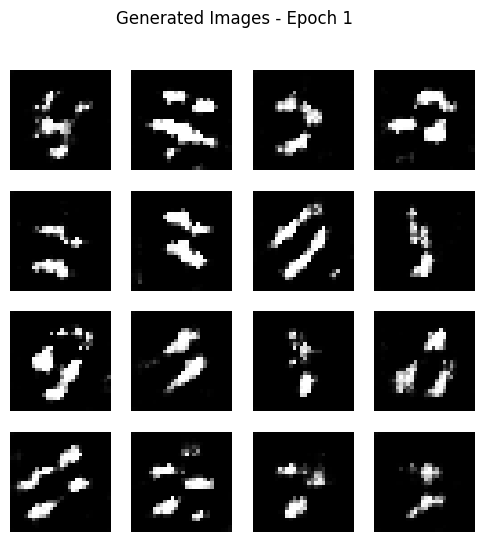

Epoch 2/20 | Generator Loss: 1.1573 | Discriminator Loss: 1.1626


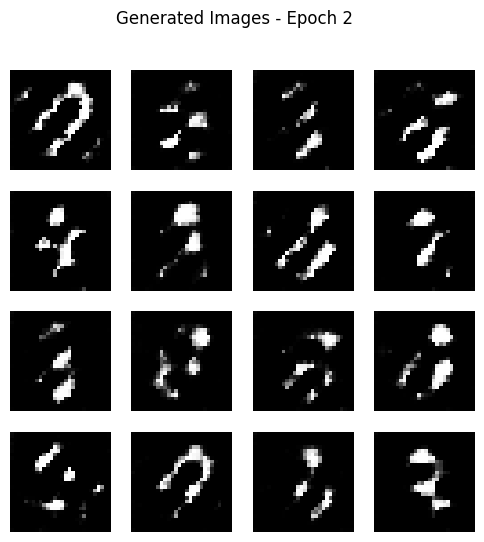

Epoch 3/20 | Generator Loss: 1.2446 | Discriminator Loss: 1.1526


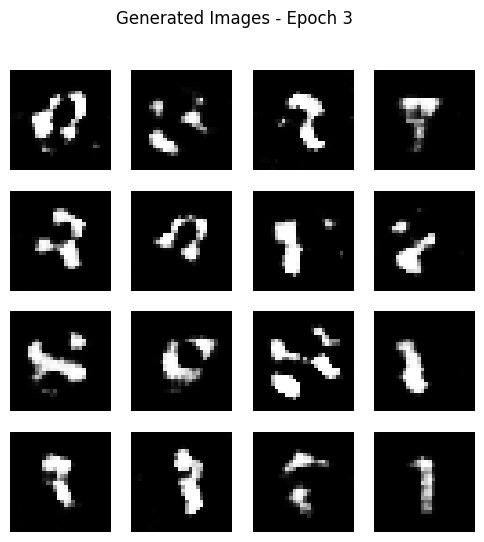

Epoch 4/20 | Generator Loss: 1.2134 | Discriminator Loss: 1.1779


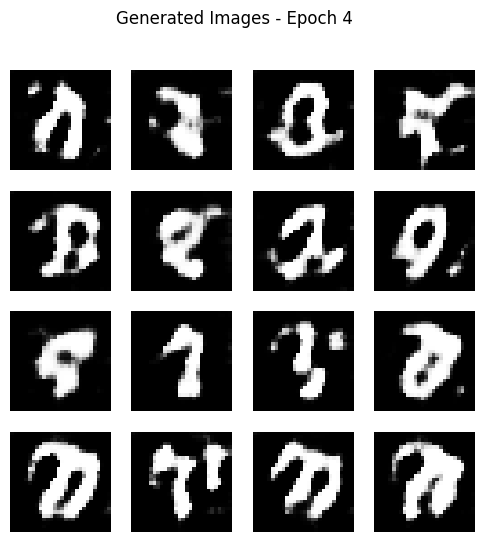

Epoch 5/20 | Generator Loss: 1.0338 | Discriminator Loss: 1.2479


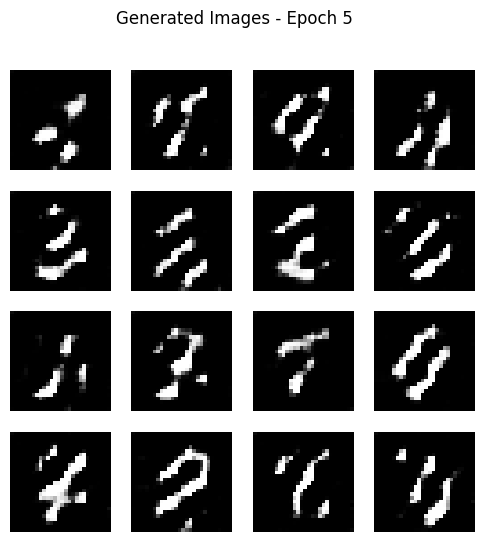

Epoch 6/20 | Generator Loss: 1.1511 | Discriminator Loss: 1.1462


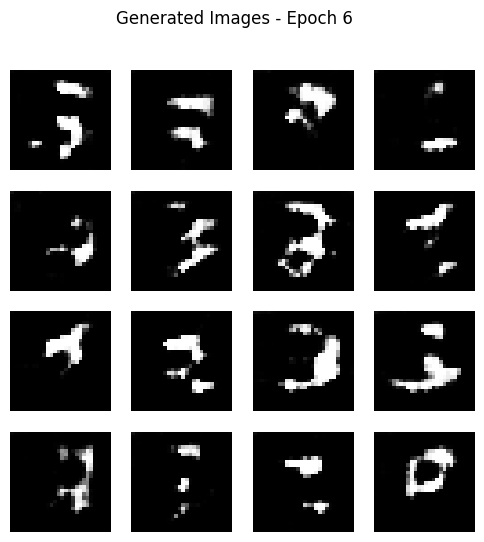

Epoch 7/20 | Generator Loss: 1.2819 | Discriminator Loss: 1.0576


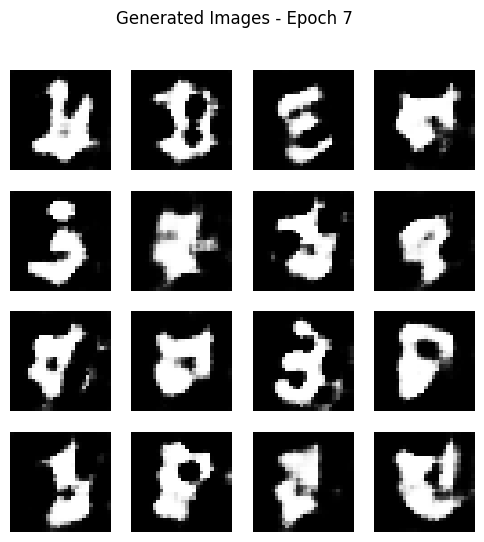

Epoch 8/20 | Generator Loss: 1.2016 | Discriminator Loss: 1.1948


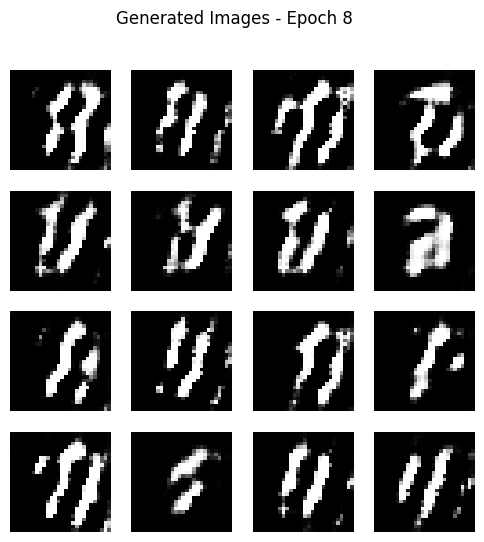

Epoch 9/20 | Generator Loss: 1.2012 | Discriminator Loss: 1.0962


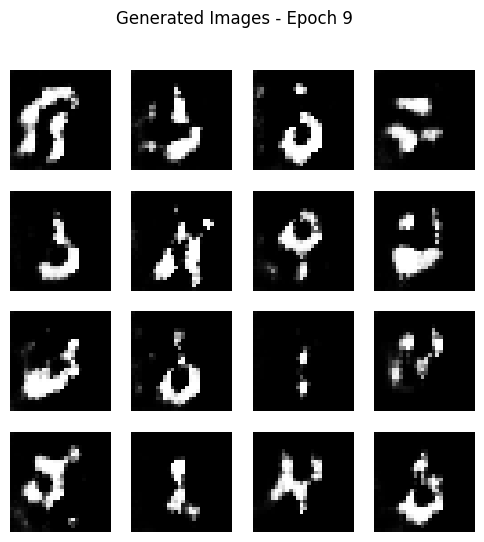

Epoch 10/20 | Generator Loss: 1.3046 | Discriminator Loss: 1.1422


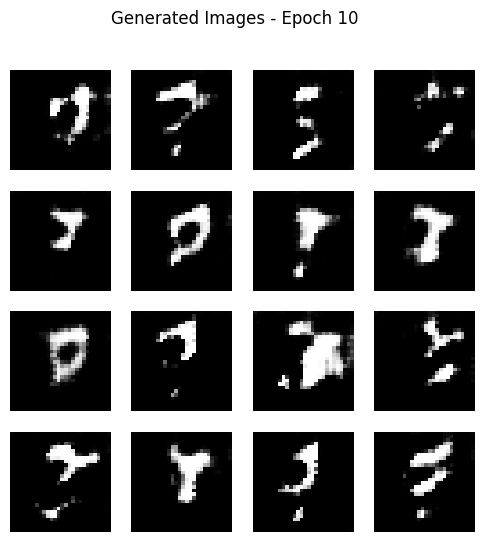

Epoch 11/20 | Generator Loss: 1.3153 | Discriminator Loss: 0.9774


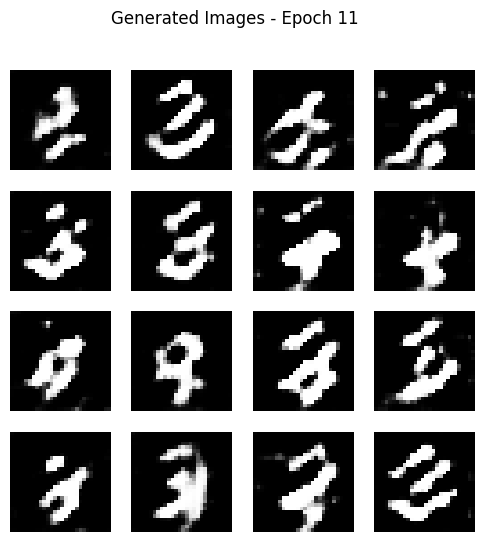

Epoch 12/20 | Generator Loss: 1.2069 | Discriminator Loss: 1.0628


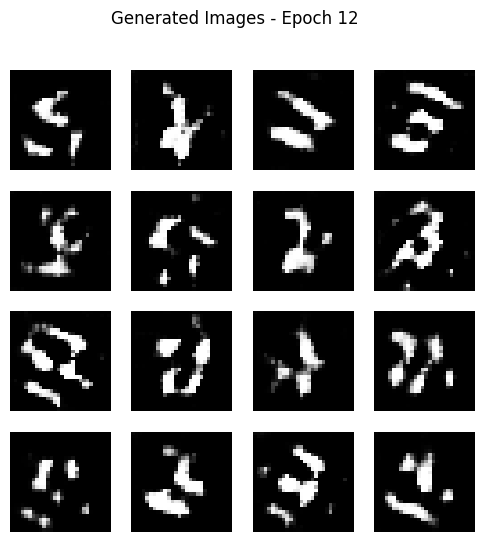

Epoch 13/20 | Generator Loss: 1.2133 | Discriminator Loss: 1.1115


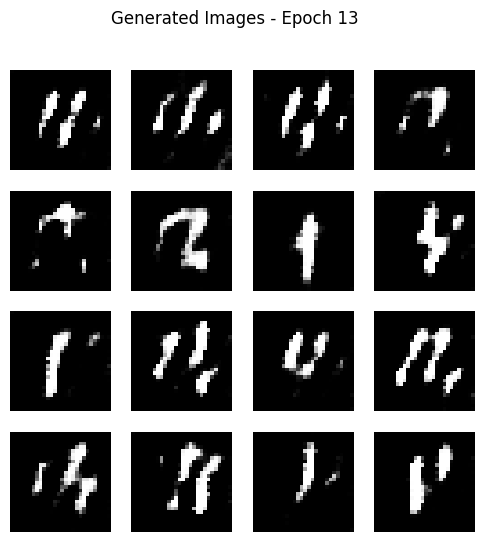

Epoch 14/20 | Generator Loss: 1.3499 | Discriminator Loss: 1.0045


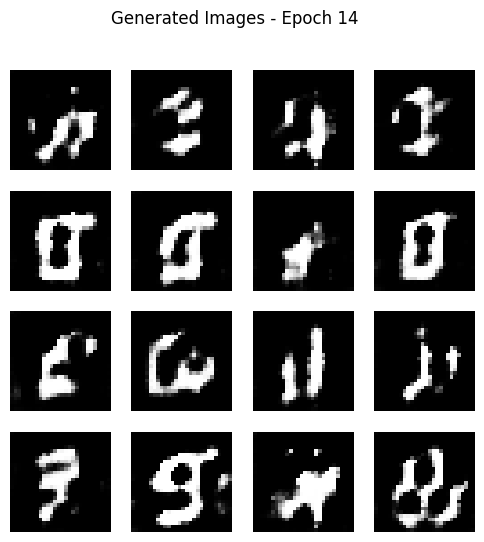

Epoch 15/20 | Generator Loss: 1.1808 | Discriminator Loss: 1.1495


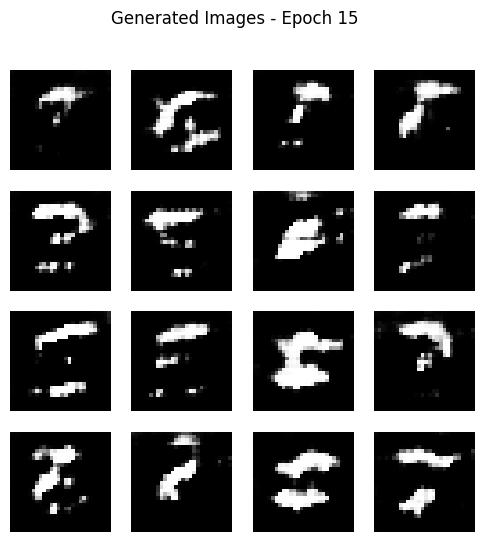

Epoch 16/20 | Generator Loss: 1.4881 | Discriminator Loss: 0.9290


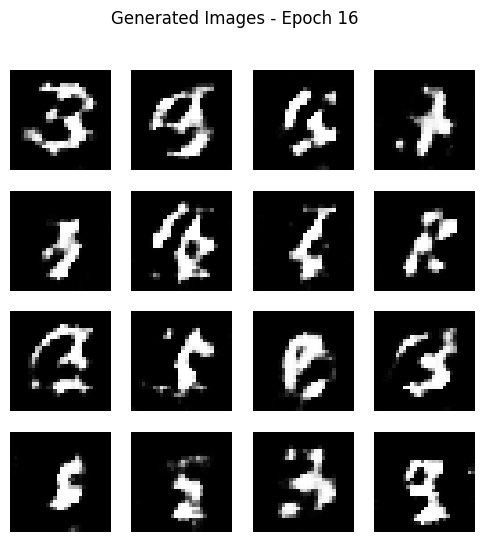

Epoch 17/20 | Generator Loss: 1.2257 | Discriminator Loss: 1.1016


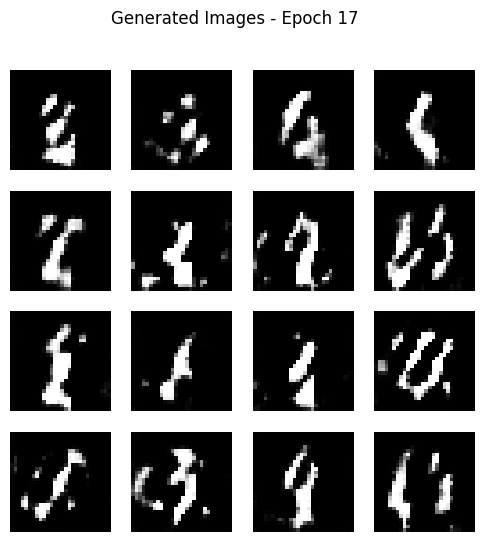

Epoch 18/20 | Generator Loss: 1.3408 | Discriminator Loss: 0.9335


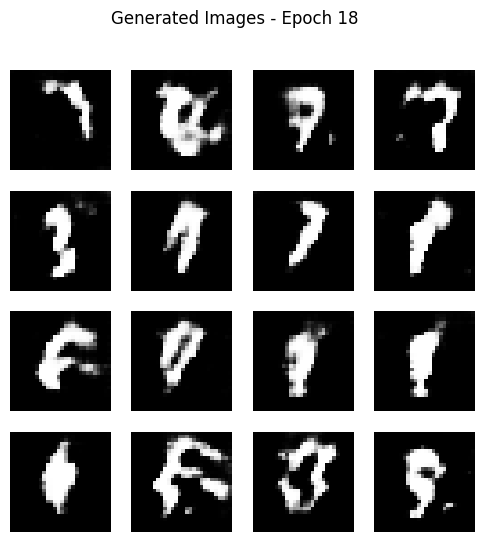

Epoch 19/20 | Generator Loss: 1.3418 | Discriminator Loss: 1.0693


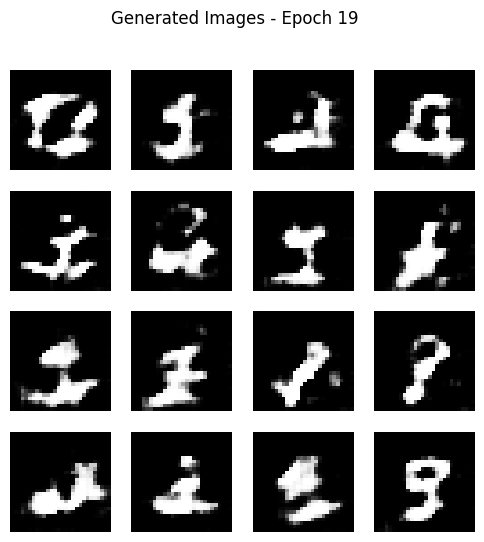

Epoch 20/20 | Generator Loss: 1.3777 | Discriminator Loss: 0.9965


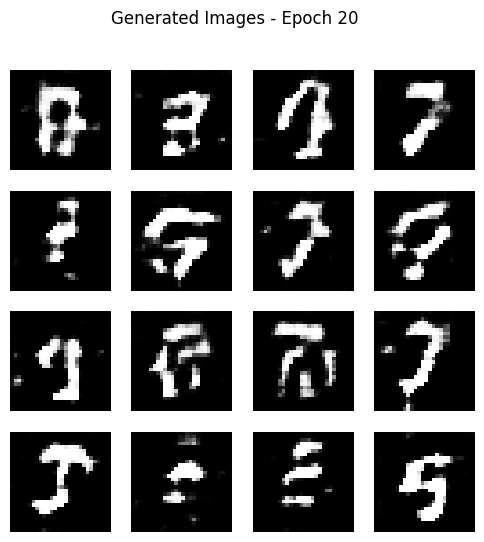

In [ ]:
EPOCHS = 20
BATCH_SIZE = 128

# Use only 10000 images for faster training
small_x_train = x_train[:10000]

dataset = tf.data.Dataset.from_tensor_slices(small_x_train)
dataset = dataset.shuffle(10000).batch(BATCH_SIZE)

generator_losses = []
discriminator_losses = []

# Make discriminator trainable
discriminator.trainable = True

for epoch in range(EPOCHS):

    g_loss_total = 0
    d_loss_total = 0
    batches = 0

    for real_images in dataset:

        batch_size = tf.shape(real_images)[0]

        # -----------------------------
        # Train Discriminator
        # -----------------------------

        noise = tf.random.normal(
            [batch_size, latent_dim]
        )

        fake_images = generator(
            noise,
            training=True
        )

        with tf.GradientTape() as tape:

            real_output = discriminator(
                real_images,
                training=True
            )

            fake_output = discriminator(
                fake_images,
                training=True
            )

            real_loss = cross_entropy(
                tf.ones_like(real_output),
                real_output
            )

            fake_loss = cross_entropy(
                tf.zeros_like(fake_output),
                fake_output
            )

            d_loss = real_loss + fake_loss

        d_gradients = tape.gradient(
            d_loss,
            discriminator.trainable_variables
        )

        discriminator.optimizer.apply_gradients(
            zip(
                d_gradients,
                discriminator.trainable_variables
            )
        )

        # -----------------------------
        # Train Generator
        # -----------------------------

        noise = tf.random.normal(
            [batch_size, latent_dim]
        )

        with tf.GradientTape() as tape:

            generated_images = generator(
                noise,
                training=True
            )

            fake_output = discriminator(
                generated_images,
                training=False
            )

            g_loss = cross_entropy(
                tf.ones_like(fake_output),
                fake_output
            )

        g_gradients = tape.gradient(
            g_loss,
            generator.trainable_variables
        )

        gan.optimizer.apply_gradients(
            zip(
                g_gradients,
                generator.trainable_variables
            )
        )

        g_loss_total += float(g_loss)
        d_loss_total += float(d_loss)
        batches += 1

    avg_g_loss = g_loss_total / batches
    avg_d_loss = d_loss_total / batches

    generator_losses.append(avg_g_loss)
    discriminator_losses.append(avg_d_loss)

    print(
        f"Epoch {epoch + 1}/{EPOCHS} | "
        f"Generator Loss: {avg_g_loss:.4f} | "
        f"Discriminator Loss: {avg_d_loss:.4f}"
    )

    # Display generated images
    noise = tf.random.normal([16, latent_dim])

    generated = generator(
        noise,
        training=False
    )

    plt.figure(figsize=(6, 6))

    for i in range(16):
        plt.subplot(4, 4, i + 1)
        plt.imshow(
            generated[i, :, :, 0],
            cmap="gray"
        )
        plt.axis("off")

    plt.suptitle(
        f"Generated Images - Epoch {epoch + 1}"
    )

    plt.show()